In [40]:
import pandas as pd
import awkward as ak
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers,Model
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [2]:
constituents_df = pd.read_csv("constituents.csv")
tags_df = pd.read_csv("tags.csv")

In [3]:
print("Constituent data sample:\n", constituents_df.head())
print("Constituent shape: ",constituents_df.shape)
print("Tag data sample:\n", tags_df.head())
print("Tags shape: ",tags_df.shape)

Constituent data sample:
    event_no  jet_no         pt       eta       phi  charge     energy
0         1       1   1.164495  0.351580 -2.296837       1   1.243080
1         1       1   1.721351  0.309108 -2.260369       0   1.804243
2         1       1   0.238875  2.112318 -1.977532       1   0.302687
3         1       1   1.052108  0.310202 -2.170598       0   1.103135
4         1       1  23.647419  0.357308 -2.067841       1  25.172964
Constituent shape:  (980476, 7)
Tag data sample:
    event_no  jet_no  IFN tag  ATLAS tag
0         1       1        1          0
1         1       2        1          1
2         2       1        1          1
3         2       2        1          1
4         3       1        1          1
Tags shape:  (19998, 4)


In [4]:
merged_df = constituents_df.merge(tags_df, on=["event_no", "jet_no"], how="inner")

In [5]:
print(merged_df.head(5))

   event_no  jet_no         pt       eta       phi  charge     energy  \
0         1       1   1.164495  0.351580 -2.296837       1   1.243080   
1         1       1   1.721351  0.309108 -2.260369       0   1.804243   
2         1       1   0.238875  2.112318 -1.977532       1   0.302687   
3         1       1   1.052108  0.310202 -2.170598       0   1.103135   
4         1       1  23.647419  0.357308 -2.067841       1  25.172964   

   IFN tag  ATLAS tag  
0        1          0  
1        1          0  
2        1          0  
3        1          0  
4        1          0  


In [6]:
grouped = merged_df.groupby(["event_no", "jet_no"])

In [7]:
features_list = []
labels_list = []

for (_, _), group in grouped:
    pt = group["pt"].values
    eta = group["eta"].values
    phi = group["phi"].values
    charge = group["charge"].values
    energy = group["energy"].values
    
    features = np.stack([pt, eta, phi, charge, energy], axis=1).astype('float32')
    features_list.append(features)

    label = group["IFN tag"].iloc[0]
    labels_list.append(label)

print(f"Number of jets: {len(features_list)}")

Number of jets: 19998


In [8]:
labels_list = [int(x) for x in labels_list]
print(len(labels_list))
print(len(features_list))

19998
19998


In [9]:
ak_features = ak.Array(features_list)
ak_labels = np.array(labels_list)

In [10]:
print("Awkward array example:", ak_features[0])
print("Labels shape:", ak_labels.shape)

Awkward array example: [[1.16, 0.352, -2.3, 1, 1.24], ..., [1.54e+03, 0.187, -2.01, -1, 1.56e+03]]
Labels shape: (19998,)


In [11]:
flat_features = np.concatenate(features_list, axis=0) 
print(flat_features.shape)

(980476, 5)


In [12]:
lengths = [len(x) for x in features_list]
row_splits = np.insert(np.cumsum(lengths), 0, 0)

In [13]:
features_ragged = tf.RaggedTensor.from_row_splits(flat_features, row_splits, validate=False)
labels_tf = tf.convert_to_tensor(ak_labels, dtype=tf.int32)

print("RaggedTensor shape:", features_ragged.shape)

RaggedTensor shape: (19998, None, 5)


2025-07-19 13:50:23.000014: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2025-07-19 13:50:23.060676: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 19609520 exceeds 10% of free system memory.


In [14]:
dataset = tf.data.Dataset.from_tensor_slices((features_ragged, labels_tf))

# Shuffle and split
N = len(labels_list)
train_size = int(0.8 * N)
val_size = N - train_size

train_dataset = dataset.take(train_size)
val_dataset = dataset.skip(train_size)

BATCH_SIZE = 64
train_dataset = train_dataset.shuffle(1000).ragged_batch(BATCH_SIZE)
val_dataset = val_dataset.ragged_batch(BATCH_SIZE)

In [35]:
EPOCHS = 10            
NUM_BLOCKS = 1          
N_HEADS = 8             
DROPOUT = 0.            
D_MODEL = 64
FF_EXPANSION = 2
FEATURE_DIM = 5

In [37]:
def make_attention_mask(mask_1d):
    mask_f = tf.cast(mask_1d, tf.float32)
    return tf.einsum('bi,bj->bij', mask_f, mask_f)

class RaggedInputsToDense(layers.Layer):
    def call(self, inputs):
        dense = inputs.to_tensor()
        row_lengths = inputs.row_lengths()
        mask = tf.sequence_mask(row_lengths, tf.shape(dense)[1])
        return dense, mask

    def compute_output_shape(self, input_shape):
        return (input_shape[0], None, input_shape[2]), (input_shape[0], None)

#Transformer Block
class TransformerBlock(layers.Layer):
    def __init__(self, d_model, num_heads, ff_expansion=2, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.mha = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model // num_heads, dropout=dropout)
        self.ffn = tf.keras.Sequential([
            layers.Dense(d_model * ff_expansion, activation='gelu'),
            layers.Dense(d_model),
        ])
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = layers.Dropout(dropout)
        self.drop2 = layers.Dropout(dropout)

    def call(self, x, attn_mask, training=False):
        attn_out = self.mha(x, x, attention_mask=attn_mask, training=training)
        x = self.norm1(x + self.drop1(attn_out, training=training))
        ffn_out = self.ffn(x, training=training)
        x = self.norm2(x + self.drop2(ffn_out, training=training))
        return x

class MaskedMeanPool(layers.Layer):
    def call(self, x, mask):
        mask_f = tf.cast(mask, x.dtype)
        summed = tf.reduce_sum(x * mask_f[..., None], axis=1)
        counts = tf.reduce_sum(mask_f, axis=1, keepdims=True)
        return summed / tf.maximum(counts, 1.0)

# Building the Model
def build_model(feature_dim=5, d_model=64, num_heads=8, num_blocks=1, ff_expansion=2, dropout=0.1):
    inputs = layers.Input(shape=(None, feature_dim), ragged=True)

    dense, mask_1d = RaggedInputsToDense()(inputs)
    x = layers.LayerNormalization(epsilon=1e-6)(dense)
    x = layers.Dense(d_model)(x)

    #Attention mask(batch, seq, seq)
    attn_mask = layers.Lambda(make_attention_mask,
                              output_shape=lambda s: (s[0], s[1], s[1]))(mask_1d)

    #Transformer blocks
    for i in range(num_blocks):
        x = TransformerBlock(d_model, num_heads, ff_expansion, dropout, name=f"block_{i}")(x, attn_mask)

    pooled = MaskedMeanPool()(x, mask_1d)
    outputs = layers.Dense(1, activation="sigmoid")(pooled)

    model = Model(inputs, outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                  loss="binary_crossentropy",
                  metrics=["AUC", "accuracy"])
    return model

model = build_model()
model.summary()


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, None, 5)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ragged_inputs_to_d… │ [(None, None, 5), │          0 │ input_layer_7[0]… │
│ (RaggedInputsToDen… │ (None, None)]     │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, None, 5)   │         10 │ ragged_inputs_to… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, None, 64)  │        384 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, None,      │          0 │ ragged_inputs_to… │
│                     │ None)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_0             │ (None, None, 64)  │     33,472 │ dense_13[0][0],   │
│ (TransformerBlock)  │                   │            │ lambda_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masked_mean_pool_2  │ (None, 64)        │          0 │ block_0[0][0],    │
│ (MaskedMeanPool)    │                   │            │ ragged_inputs_to… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 1)         │         65 │ masked_mean_pool… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 33,931 (132.54 KB)

 Trainable params: 33,931 (132.54 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
model = build_model(
    feature_dim=FEATURE_DIM,
    d_model=D_MODEL,
    num_heads=N_HEADS,
    num_blocks=NUM_BLOCKS,   
    ff_expansion=FF_EXPANSION,
    dropout=0.1              
)
model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, None, 5)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ragged_inputs_to_d… │ [(None, None, 5), │          0 │ input_layer_9[0]… │
│ (RaggedInputsToDen… │ (None, None)]     │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, None, 5)   │         10 │ ragged_inputs_to… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, None, 64)  │        384 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, None,      │          0 │ ragged_inputs_to… │
│                     │ None)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_0             │ (None, None, 64)  │     33,472 │ dense_17[0][0],   │
│ (TransformerBlock)  │                   │            │ lambda_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masked_mean_pool_3  │ (None, 64)        │          0 │ block_0[0][0],    │
│ (MaskedMeanPool)    │                   │            │ ragged_inputs_to… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 1)         │         65 │ masked_mean_pool… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 33,931 (132.54 KB)

 Trainable params: 33,931 (132.54 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
callbacks = [
    EarlyStopping(monitor="val_AUC", mode="max", patience=5, restore_best_weights=True),
    ModelCheckpoint("best_transformer_qg.h5", monitor="val_auc", mode="max",
                    save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor="val_AUC", mode="max", factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1)
]

In [52]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,                 # use early stopping instead of a hard 10
    #callbacks=callbacks, 
    verbose=1
)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 94s 377ms/step - AUC: 0.5340 - accuracy: 0.9466 - loss: 0.2082 - val_AUC: 0.5534 - val_accuracy: 0.9492 - val_loss: 0.1994
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 97s 387ms/step - AUC: 0.5609 - accuracy: 0.9474 - loss: 0.2043 - val_AUC: 0.5603 - val_accuracy: 0.9492 - val_loss: 0.2000
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 101s 402ms/step - AUC: 0.5528 - accuracy: 0.9479 - loss: 0.2033 - val_AUC: 0.5500 - val_accuracy: 0.9492 - val_loss: 0.2006
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 105s 419ms/step - AUC: 0.5533 - accuracy: 0.9494 - loss: 0.1995 - val_AUC: 0.5594 - val_accuracy: 0.9492 - val_loss: 0.1992
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 99s 398ms/step - AUC: 0.5564 - accuracy: 0.9480 - loss: 0.2030 - val_AUC: 0.5551 - val_accuracy: 0.9492 - val_loss: 0.2001
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 101s 404ms/step - AUC: 0.5508 - accuracy: 0.9471 - loss: 0.2059 - val_AUC: 0.5597 - val_accuracy: 0.9492 - val_loss: 0.1995
Epoch 7/10
250/250 

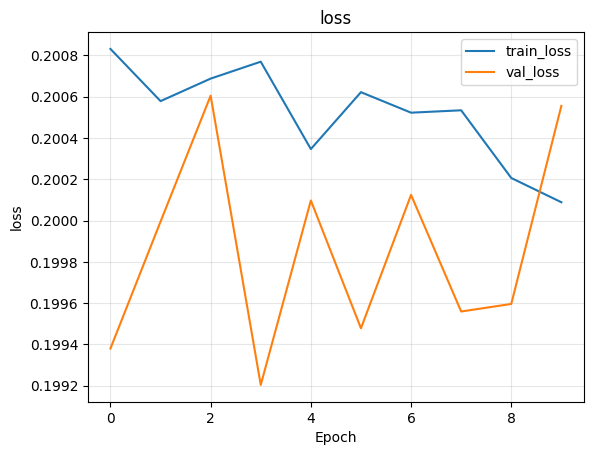

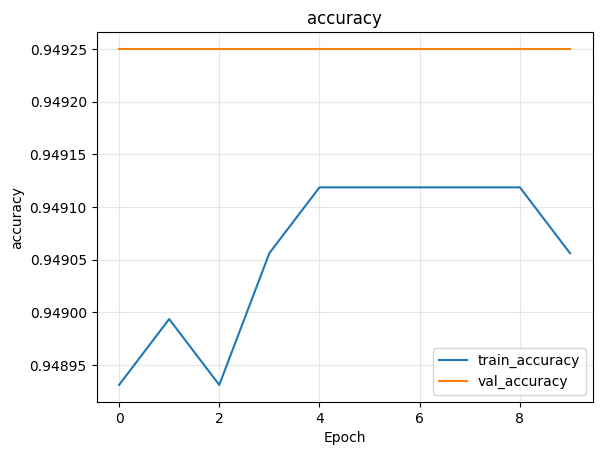

In [53]:
hist = history.history

def plot_metric(name):
    plt.figure()
    plt.plot(hist[name], label=f"train_{name}")
    plt.plot(hist[f"val_{name}"], label=f"val_{name}")
    plt.xlabel("Epoch")
    plt.ylabel(name)
    plt.title(name)
    plt.legend()
    plt.grid(alpha=0.3)

for metric in ["loss", "auc", "accuracy"]:
    if metric in hist:
        plot_metric(metric)
plt.show()

Validation ROC AUC (manual): 0.562206


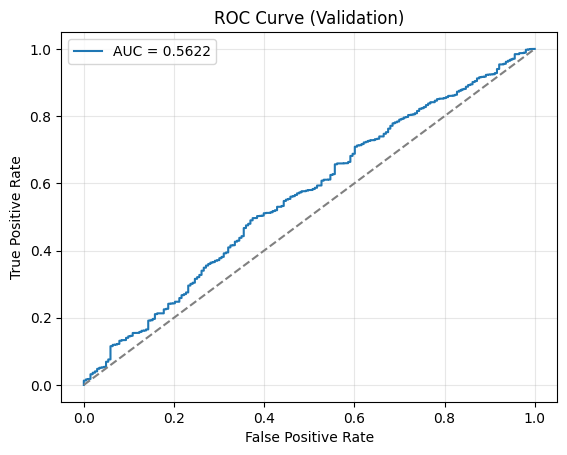

Confusion Matrix:
 [[   0  203]
 [   0 3797]]
Classification Report:
               precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       203
           1     0.9493    1.0000    0.9740      3797

    accuracy                         0.9493      4000
   macro avg     0.4746    0.5000    0.4870      4000
weighted avg     0.9011    0.9493    0.9245      4000



/home/aritra/HEP/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/aritra/HEP/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/aritra/HEP/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [54]:
y_true = []
y_prob = []
for feats_batch, lbl_batch in val_dataset:
    preds = model(feats_batch, training=False)
    y_true.append(lbl_batch.numpy())
    y_prob.append(preds.numpy().ravel())

y_true = np.concatenate(y_true)
y_prob = np.concatenate(y_prob)

fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)
print(f"Validation ROC AUC (manual): {roc_auc:.6f}")

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],"--", color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Validation)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Default threshold 0.5
y_pred = (y_prob >= 0.5).astype(int)
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)
print("Classification Report:\n", classification_report(y_true, y_pred, digits=4))